<a href="https://colab.research.google.com/github/nirmalprabhakarc/Machine-Learning-Alogarithms/blob/main/Self_Organizing_Maps_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
URK21CS2060
nirmal

In [ ]:
Aim:
 To implement the SOM model to perform clustering, and to evaluate the performance of the model.
Description:
    Self-Organizing Maps (SOM) are neural network models used for clustering and dimensionality reduction. SOMs organize high-dimensional data onto a lower-dimensional grid while preserving the topological relationships between data points. During training, neurons compete to represent input data, and the winning neuron and its neighbors adjust their weights to better match the input. This process results in a grid where adjacent neurons represent similar data points, facilitating clustering.

    To evaluate the performance of SOM clustering, several metrics can be employed. Quantization error measures the average distance between input data points and their corresponding winning neurons on the SOM grid. Topographic error assesses the preservation of the data's topological relationships on the grid. Silhouette score evaluates the compactness and separation of clusters formed by the SOM. Additionally, visual inspection of the SOM grid and domain-specific metrics can provide insights into the clustering quality and its relevance to the problem at hand.

    By employing these evaluation techniques, practitioners can assess the effectiveness of SOM clustering and gain valuable insights into the structure of the underlying data. This facilitates exploratory data analysis, visualization, and decision-making processes in various domains, enhancing the utility of SOMs for clustering tasks.

In [ ]:
# 1. Import necessary python libraries
print('URK21CS2060')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

URK21CS3016


In [ ]:
# 2. Read the dataset
print('URK21CS2060')
data = pd.read_csv('B5_wineFCM.csv')

URK21CS3016


In [ ]:
# 3. Missing value imputation using mean for the specific column (if required)
print('URK21CS2060')
if data.isnull().values.any():
    data.fillna(data.mean(), inplace=True)

URK21CS3016


In [ ]:
# 4. Standardize the data using StandardScaler
print('URK21CS2060')
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

URK21CS3016


URK21CS3016


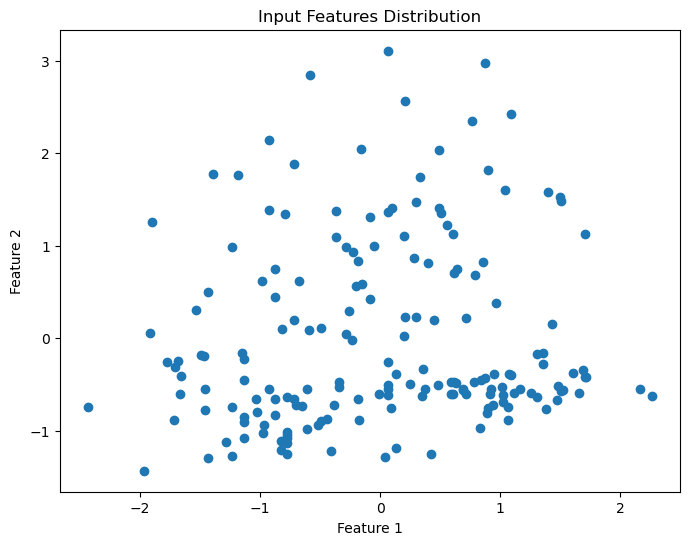

In [ ]:
# 5. Visualize the input features distribution using scatter plot
print('URK21CS2060')
plt.figure(figsize=(8, 6))
plt.scatter(data_scaled[:, 0], data_scaled[:, 1])
plt.title('Input Features Distribution')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [ ]:
# 6. Perform the SOM clustering with different number of clusters and decide optimal number of clusters between (2 to 5) using silhouette score (max)
print('URK21CS2060')
import numpy as np
from sklearn.metrics import silhouette_score

class SOM:
    def __init__(self, input_dim, map_size):
        self.weights = np.random.rand(*map_size, input_dim)

    def train(self, data, num_epochs=100, learning_rate=0.1, sigma=1):
        for epoch in range(num_epochs):
            for sample in data:
                bmu = self.find_best_matching_unit(sample)
                self.update_weights(sample, bmu, learning_rate, sigma)

    def find_best_matching_unit(self, sample):
        distances = np.linalg.norm(self.weights - sample, axis=2)
        return np.unravel_index(np.argmin(distances), distances.shape)

    def update_weights(self, sample, bmu, learning_rate, sigma):
        for x in range(self.weights.shape[0]):
            for y in range(self.weights.shape[1]):
                distance = np.linalg.norm([x - bmu[0], y - bmu[1]])
                if distance < sigma:
                    self.weights[x, y] += learning_rate * (sample - self.weights[x, y])

# Define the range of clusters
n_clusters_range = range(2, 6)
silhouette_scores = []

# Perform SOM clustering with different numbers of clusters
for n_clusters in n_clusters_range:
    som = SOM(input_dim=data_scaled.shape[1], map_size=(n_clusters, 1))
    som.train(data_scaled, num_epochs=100, learning_rate=0.1, sigma=1)
    cluster_labels = np.array([som.find_best_matching_unit(x)[0] for x in data_scaled])
    silhouette_scores.append(silhouette_score(data_scaled, cluster_labels))

# Determine the optimal number of clusters based on the silhouette score
optimal_n_clusters = n_clusters_range[np.argmax(silhouette_scores)]
print('Optimal number of clusters between (2 to 5):', optimal_n_clusters)


URK21CS3016


/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:193: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:193: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:193: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Optimal number of clusters between (2 to 5): 3


/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:193: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


URK21CS3016


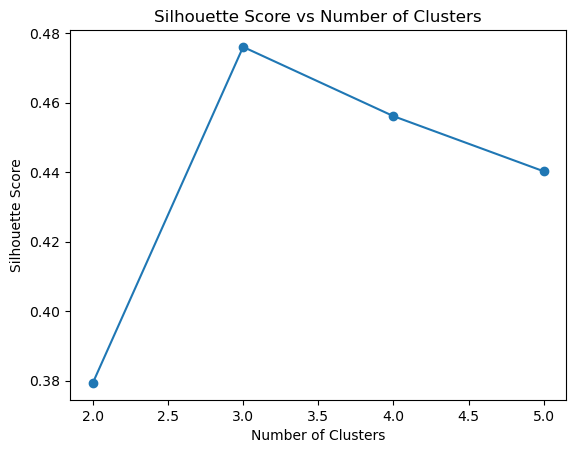

In [ ]:
# 7. Plot the curve against the number of clusters and the silhouette score.
print('URK21CS2060')
plt.plot(n_clusters_range, silhouette_scores, marker='o')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [ ]:
# 8. For the selected optimal number of clusters, display the cluster centroids.
print('URK21CS2060')
som_optimal = SOM(input_dim=data_scaled.shape[1], map_size=(optimal_n_clusters, 1))
som_optimal.train(data_scaled, num_epochs=100, learning_rate=0.1, sigma=1)

# Extract cluster centroids
cluster_centroids = som_optimal.weights.reshape(-1, data_scaled.shape[1])

print("Cluster Centroids for Optimal Number of Clusters:")
for i, centroid in enumerate(cluster_centroids):
    print(f"Cluster {i+1} centroid: {centroid}")


URK21CS3016
Cluster Centroids for Optimal Number of Clusters:
Cluster 1 centroid: [ 0.6968419 -0.3354412]
Cluster 2 centroid: [-0.83561433 -0.13368648]
Cluster 3 centroid: [0.43211407 1.5510458 ]


URK21CS3016


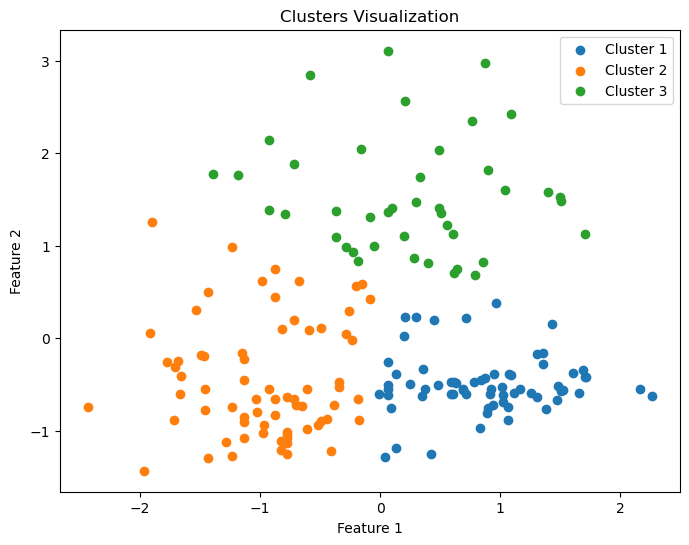

In [ ]:
# 9. Visualize the clusters using scatter plot with labels.
print('URK21CS2060')
# Visualize the clusters using scatter plot with labels
plt.figure(figsize=(8, 6))

# Assigning cluster labels to each data point
cluster_labels = np.array([som_optimal.find_best_matching_unit(x)[0] for x in data_scaled])

# Plotting each cluster
for i in range(optimal_n_clusters):
    cluster_data = data_scaled[cluster_labels == i]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], label=f'Cluster {i+1}')

plt.title('Clusters Visualization')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

In [ ]:
# 10. Display the optimal silhouette score.
print('URK21CS2060')
print("Optimal Silhouette Score:", max(silhouette_scores))

URK21CS3016
Optimal Silhouette Score: 0.47600791132805237


In [ ]:
Result:
  Thus the SOM model to perform clustering has been implemented, and the performance of the model has been evaluated.